<a href="https://colab.research.google.com/github/mrushad/ml4qs-G39/blob/main/notebooks/mlqs_lydia.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Imports

In [35]:
import os
import pandas as pd
import numpy as np

# Cloning github repo to access data

In [36]:
!git clone https://github.com/mrushad/ml4qs-G39

Cloning into 'ml4qs-G39'...
remote: Enumerating objects: 133, done.
remote: Counting objects: 100% (133/133), done.
remote: Compressing objects: 100% (127/127), done.
remote: Total 133 (delta 33), reused 32 (delta 3), pack-reused 0 (from 0)
Receiving objects: 100% (133/133), 32.71 MiB | 9.88 MiB/s, done.
Resolving deltas: 100% (33/33), done.


# Functions

## read_csv_files()

In [37]:
def read_csv_files():
  csv_files = [
      'Accelerometer.csv',
      'Linear Accelerometer.csv',
      'Barometer.csv',
      'Location.csv',
      'Gyroscope.csv',
      'Magnetometer.csv',
      'Proximity.csv'
  ]

  # Dictionary to store DataFrames
  dfs = {}

  for filename in csv_files:
      try:
          # Create a clean DataFrame name (e.g., 'Accelerometer_df')
          df_name = filename.replace('.csv', '') + '_df'

          # Read the CSV file
          df = pd.read_csv(filename)

          # Store it in the dictionary
          dfs[df_name] = df

          print(f"Loaded '{filename}' into DataFrame '{df_name}'. Shape: {df.shape}")
          # Optional: Display the first few rows to verify
          # print(dfs[df_name].head())

      except FileNotFoundError:
          print(f"Error: '{filename}' not found in the current directory ({os.getcwd()}).")
      except Exception as e:
          print(f"Error loading '{filename}': {e}")

  # --- Accessing your DataFrames ---

  # You can now access your DataFrames like this:
  if 'Accelerometer_df' in dfs:
      print("\nAccelerometer_df head:")
      print(dfs['Accelerometer_df'].head())

  if 'Gyroscope_df' in dfs:
      print("\nGyroscope_df head:")
      print(dfs['Gyroscope_df'].head())

  # Or iterate through them
  print("\n--- All loaded DataFrames ---")
  for name, df in dfs.items():
      print(f"DataFrame: {name}, Columns: {df.columns.tolist()}, Shape: {df.shape}")
  return dfs

## combine_dfs()

In [38]:
def combine_dfs(sensor_dfs):
    # Initialize an empty list to store processed DataFrames
    processed_dfs = []

    # Process each DataFrame
    for sensor_name, df in sensor_dfs.items(): # Iterate using the 'sensor_dfs' for cleaner prefixes
        # Create a copy to avoid modifying the original DataFrame directly
        df_copy = df.copy()

        # Round the 'Time (s)' column to three decimal places
        df_copy['Time (s)'] = df_copy['Time (s)'].round(2)

        # Rename columns to include the sensor name as a prefix
        new_columns = {}
        for col in df_copy.columns:
            if col != 'Time (s)':
                # Replace spaces in column names with underscores for consistency
                # Also remove parentheses from the unit part of the column name
                new_col_name = f"{sensor_name}_{col.replace(' ', '_').replace('(', '').replace(')', '')}"
                new_columns[col] = new_col_name
        df_copy = df_copy.rename(columns=new_columns)
        processed_dfs.append(df_copy) # Correctly append to 'processed_dfs'

    # Merge all processed DataFrames based on the 'Time (s)' column
    # Start with the first processed DataFrame
    if processed_dfs:
        combined_df = processed_dfs[0] # Use 'processed_dfs' for merging
        for i in range(1, len(processed_dfs)):
            combined_df = pd.merge(combined_df, processed_dfs[i], on='Time (s)', how='outer')

        # Display the combined DataFrame information
        print("Combined DataFrame Head:")
        print(combined_df.head())
        print("\nCombined DataFrame Info:")
        combined_df.info()
    else:
        print("No DataFrames to combine.")
    return combined_df

## identify_correlation()

In [39]:
def identify_correlation(df, correlation_method='spearman', correlation_threshold=0.6):

    correlation = biking_df.corr(method=correlation_method)
    correlation_threshold = 0.60

    print(f"Pairs with Strong Spearman Correlation (absolute value >= {correlation_threshold}):\n")
    num_cols = len(correlation.columns)
    found_strong_correlation = False

    for i in range(num_cols):
        for j in range(i + 1, num_cols):
            var1 = correlation.columns[i]
            var2 = correlation.columns[j]
            correlation_value = correlation.iloc[i, j]

            if abs(correlation_value) >= correlation_threshold:
                print(f"  {var1} vs {var2}: {correlation_value:.4f}")
                found_strong_correlation = True

    if not found_strong_correlation:
        print("  No pairs found with strong Spearman correlation above the threshold.")

# CSV to DF

## Biking Data

In [40]:
os.chdir('ml4qs-G39')
!ls -F

data/  LICENSE	notebooks/  README.md  reports/  requirements.txt  src/


In [41]:
%cd data/raw

/content/ml4qs-G39/data/raw/WalkingData1 2025-06-06 15-30-08/ml4qs-G39/data/raw


In [42]:
!ls -F

'BikingData1 2025-06-06 10-48-07'/   'Metro1 2025-06-19 14-43-22'/
'DrivingData1 2025-06-19 19-26-19'/  'Metro2 2025-06-19 17-05-44'/
'DrivingData2 2025-06-19 14-30-43'/  'WalkingData1 2025-06-06 15-30-08'/
'DrivingData3 2025-06-19 15-40-50'/


In [43]:
%cd BikingData1 2025-06-06 10-48-07

/content/ml4qs-G39/data/raw/WalkingData1 2025-06-06 15-30-08/ml4qs-G39/data/raw/BikingData1 2025-06-06 10-48-07


In [44]:
!ls -F

 Accelerometer.csv  'Linear Accelerometer.csv'	 meta/
 Barometer.csv	     Location.csv		 Proximity.csv
 Gyroscope.csv	     Magnetometer.csv


In [45]:
biking_dfs = read_csv_files()
bkining_accelerometer_df = biking_dfs['Accelerometer_df']
bkining_linear_accelerometer_df = biking_dfs['Linear Accelerometer_df']
bkining_barometer_df = biking_dfs['Barometer_df']
bkining_location_df = biking_dfs['Location_df']
bkining_gyroscope_df = biking_dfs['Gyroscope_df']
bkining_magnetometer_df = biking_dfs['Magnetometer_df']
bkining_proximity_df = biking_dfs['Proximity_df']

Loaded 'Accelerometer.csv' into DataFrame 'Accelerometer_df'. Shape: (90430, 4)
Loaded 'Linear Accelerometer.csv' into DataFrame 'Linear Accelerometer_df'. Shape: (90430, 4)
Loaded 'Barometer.csv' into DataFrame 'Barometer_df'. Shape: (847, 2)
Loaded 'Location.csv' into DataFrame 'Location_df'. Shape: (900, 8)
Loaded 'Gyroscope.csv' into DataFrame 'Gyroscope_df'. Shape: (90430, 4)
Loaded 'Magnetometer.csv' into DataFrame 'Magnetometer_df'. Shape: (90430, 4)
Loaded 'Proximity.csv' into DataFrame 'Proximity_df'. Shape: (66, 2)

Accelerometer_df head:
   Time (s)  X (m/s^2)  Y (m/s^2)  Z (m/s^2)
0  0.008161  -1.333277   8.060289   8.314460
1  0.018114  -1.519939   8.037236   6.289621
2  0.028068  -1.010099   7.053333   4.551286
3  0.038021  -0.723446   6.263126   5.793253
4  0.047974  -0.928819   6.392906   6.570437

Gyroscope_df head:
   Time (s)  X (rad/s)  Y (rad/s)  Z (rad/s)
0  0.010650  -0.048301   0.043927   0.077801
1  0.020603  -0.013787  -0.115126   0.007624
2  0.030556   0.0621

In [46]:
biking_df = combine_dfs(biking_dfs)
biking_df.head()

Combined DataFrame Head:
   Time (s)  Accelerometer_df_X_m/s^2  Accelerometer_df_Y_m/s^2  \
0     -0.54                       NaN                       NaN   
1      0.01                 -1.333277                  8.060289   
2      0.02                 -1.519939                  8.037236   
3      0.03                 -1.010099                  7.053333   
4      0.04                 -0.723446                  6.263126   

   Accelerometer_df_Z_m/s^2  Linear Accelerometer_df_X_m/s^2  \
0                       NaN                              NaN   
1                  8.314460                        -0.571053   
2                  6.289621                        -0.663435   
3                  4.551286                        -0.093932   
4                  5.793253                         0.074273   

   Linear Accelerometer_df_Y_m/s^2  Linear Accelerometer_df_Z_m/s^2  \
0                              NaN                              NaN   
1                         0.853277           

,Time (s),Accelerometer_df_X_m/s^2,Accelerometer_df_Y_m/s^2,Accelerometer_df_Z_m/s^2,Linear Accelerometer_df_X_m/s^2,Linear Accelerometer_df_Y_m/s^2,Linear Accelerometer_df_Z_m/s^2,Barometer_df_X_hPa,Location_df_Latitude_°,Location_df_Longitude_°,...,Location_df_Direction_°,Location_df_Horizontal_Accuracy_m,Location_df_Vertical_Accuracy_°,Gyroscope_df_X_rad/s,Gyroscope_df_Y_rad/s,Gyroscope_df_Z_rad/s,Magnetometer_df_X_µT,Magnetometer_df_Y_µT,Magnetometer_df_Z_µT,Proximity_df_Distance_cm
0,-0.54,NaN,NaN,NaN,NaN,NaN,NaN,1006.42868,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.01,-1.333277,8.060289,8.314460,-0.571053,0.853277,1.423410,NaN,NaN,NaN,...,NaN,NaN,NaN,-0.048301,0.043927,0.077801,-3.454794,-47.541077,-15.692932,NaN
2,0.02,-1.519939,8.037236,6.289621,-0.663435,0.548666,-0.828132,NaN,NaN,NaN,...,NaN,NaN,NaN,-0.013787,-0.115126,0.007624,-3.275377,-47.394699,-15.088928,5.0
3,0.03,-1.010099,7.053333,4.551286,-0.093932,-0.504608,-1.861800,NaN,NaN,NaN,...,NaN,NaN,NaN,0.062199,-0.121075,0.037894,-3.161579,-47.449356,-15.146851,NaN
4,0.04,-0.723446,6.263126,5.793253,0.074273,-1.115019,-0.295147,NaN,NaN,NaN,...,NaN,NaN,NaN,0.162161,-0.012193,0.098252,-3.133875,-47.220291,-15.232971,NaN


## Walking Data

In [47]:
%cd ../
!ls -F

/content/ml4qs-G39/data/raw/WalkingData1 2025-06-06 15-30-08/ml4qs-G39/data/raw
'BikingData1 2025-06-06 10-48-07'/   'Metro1 2025-06-19 14-43-22'/
'DrivingData1 2025-06-19 19-26-19'/  'Metro2 2025-06-19 17-05-44'/
'DrivingData2 2025-06-19 14-30-43'/  'WalkingData1 2025-06-06 15-30-08'/
'DrivingData3 2025-06-19 15-40-50'/


In [48]:
%cd WalkingData1 2025-06-06 15-30-08

/content/ml4qs-G39/data/raw/WalkingData1 2025-06-06 15-30-08/ml4qs-G39/data/raw/WalkingData1 2025-06-06 15-30-08


In [49]:
!ls -F

 Accelerometer.csv  'Linear Accelerometer.csv'	 meta/
 Barometer.csv	     Location.csv		 Proximity.csv
 Gyroscope.csv	     Magnetometer.csv


In [50]:
walking_dfs = read_csv_files()
walking_accelerometer_df = walking_dfs['Accelerometer_df']
walking_linear_accelerometer_df = walking_dfs['Linear Accelerometer_df']
walking_barometer_df = walking_dfs['Barometer_df']
walking_location_df = walking_dfs['Location_df']
walking_gyroscope_df = walking_dfs['Gyroscope_df']
walking_magnetometer_df = walking_dfs['Magnetometer_df']
walking_proximity_df = walking_dfs['Proximity_df']

Loaded 'Accelerometer.csv' into DataFrame 'Accelerometer_df'. Shape: (90423, 4)
Loaded 'Linear Accelerometer.csv' into DataFrame 'Linear Accelerometer_df'. Shape: (90423, 4)
Loaded 'Barometer.csv' into DataFrame 'Barometer_df'. Shape: (847, 2)
Loaded 'Location.csv' into DataFrame 'Location_df'. Shape: (899, 8)
Loaded 'Gyroscope.csv' into DataFrame 'Gyroscope_df'. Shape: (90423, 4)
Loaded 'Magnetometer.csv' into DataFrame 'Magnetometer_df'. Shape: (90423, 4)
Loaded 'Proximity.csv' into DataFrame 'Proximity_df'. Shape: (1, 2)

Accelerometer_df head:
   Time (s)  X (m/s^2)  Y (m/s^2)  Z (m/s^2)
0  0.002582  -2.956801   3.204536  12.733271
1  0.012535  -1.568887   2.797832  11.682157
2  0.022488  -0.466879   3.101850  10.308014
3  0.032441  -1.001867   3.238216   8.759784
4  0.042394  -1.313219   2.810705   8.288564

Gyroscope_df head:
   Time (s)  X (rad/s)  Y (rad/s)  Z (rad/s)
0  0.000094  -0.010970   0.069035   0.648594
1  0.010047   0.057596   0.260039   0.495670
2  0.020000  -0.00142

In [51]:
walking_df = combine_dfs(walking_dfs)
walking_df.head()

Combined DataFrame Head:
   Time (s)  Accelerometer_df_X_m/s^2  Accelerometer_df_Y_m/s^2  \
0     -0.53                       NaN                       NaN   
1      0.00                 -2.956801                  3.204536   
2      0.01                 -1.568887                  2.797832   
3      0.02                 -0.466879                  3.101850   
4      0.03                 -1.001867                  3.238216   

   Accelerometer_df_Z_m/s^2  Linear Accelerometer_df_X_m/s^2  \
0                       NaN                              NaN   
1                 12.733271                        -2.192563   
2                 11.682157                        -0.712324   
3                 10.308014                         0.602520   
4                  8.759784                         0.422396   

   Linear Accelerometer_df_Y_m/s^2  Linear Accelerometer_df_Z_m/s^2  \
0                              NaN                              NaN   
1                        -0.171700           

,Time (s),Accelerometer_df_X_m/s^2,Accelerometer_df_Y_m/s^2,Accelerometer_df_Z_m/s^2,Linear Accelerometer_df_X_m/s^2,Linear Accelerometer_df_Y_m/s^2,Linear Accelerometer_df_Z_m/s^2,Barometer_df_X_hPa,Location_df_Latitude_°,Location_df_Longitude_°,...,Location_df_Direction_°,Location_df_Horizontal_Accuracy_m,Location_df_Vertical_Accuracy_°,Gyroscope_df_X_rad/s,Gyroscope_df_Y_rad/s,Gyroscope_df_Z_rad/s,Magnetometer_df_X_µT,Magnetometer_df_Y_µT,Magnetometer_df_Z_µT,Proximity_df_Distance_cm
0,-0.53,NaN,NaN,NaN,NaN,NaN,NaN,1008.348923,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.00,-2.956801,3.204536,12.733271,-2.192563,-0.171700,4.255854,NaN,NaN,NaN,...,NaN,NaN,NaN,-0.010970,0.069035,0.648594,-21.498955,-16.158371,-37.334290,5.0
2,0.01,-1.568887,2.797832,11.682157,-0.712324,-0.519467,2.735299,NaN,NaN,NaN,...,NaN,NaN,NaN,0.057596,0.260039,0.495670,-21.380814,-16.132431,-36.897217,NaN
3,0.02,-0.466879,3.101850,10.308014,0.602520,-0.465167,1.634350,NaN,NaN,NaN,...,NaN,NaN,NaN,-0.001422,0.377463,0.281415,-21.289383,-16.068405,-37.185730,NaN
4,0.03,-1.001867,3.238216,8.759784,0.422396,-0.109258,-0.077208,NaN,NaN,NaN,...,NaN,NaN,NaN,-0.137912,0.269675,0.173701,-21.026146,-15.975693,-37.676147,NaN


# Cleaning

## Filling Nulls using interpolaration

In [52]:
biking_df.isnull().sum()

,0
Time (s),0
Accelerometer_df_X_m/s^2,1
Accelerometer_df_Y_m/s^2,1
Accelerometer_df_Z_m/s^2,1
Linear Accelerometer_df_X_m/s^2,1
Linear Accelerometer_df_Y_m/s^2,1
Linear Accelerometer_df_Z_m/s^2,1
Barometer_df_X_hPa,92560
Location_df_Latitude_°,92523
Location_df_Longitude_°,92523


In [53]:
walking_df.isnull().sum()

,0
Time (s),0
Accelerometer_df_X_m/s^2,1
Accelerometer_df_Y_m/s^2,1
Accelerometer_df_Z_m/s^2,1
Linear Accelerometer_df_X_m/s^2,1
Linear Accelerometer_df_Y_m/s^2,1
Linear Accelerometer_df_Z_m/s^2,1
Barometer_df_X_hPa,92479
Location_df_Latitude_°,92439
Location_df_Longitude_°,92439


In [54]:
# Interpolate all columns in biking_df
for col in biking_df.columns:
    if biking_df[col].isnull().any():
        biking_df[col].interpolate(method='linear', inplace=True)

# Interpolate all columns in walking_df
for col in walking_df.columns:
    if walking_df[col].isnull().any():
        walking_df[col].interpolate(method='linear', inplace=True)

print("Interpolation complete for biking_df:")
print(biking_df.isnull().sum())

print("\nInterpolation complete for walking_df:")
print(walking_df.isnull().sum())

/tmp/ipython-input-54-2452346011.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  biking_df[col].interpolate(method='linear', inplace=True)


Interpolation complete for biking_df:
Time (s)                              0
Accelerometer_df_X_m/s^2              1
Accelerometer_df_Y_m/s^2              1
Accelerometer_df_Z_m/s^2              1
Linear Accelerometer_df_X_m/s^2       1
Linear Accelerometer_df_Y_m/s^2       1
Linear Accelerometer_df_Z_m/s^2       1
Barometer_df_X_hPa                    0
Location_df_Latitude_°               81
Location_df_Longitude_°              81
Location_df_Height_m                 81
Location_df_Velocity_m/s             81
Location_df_Direction_°              81
Location_df_Horizontal_Accuracy_m    81
Location_df_Vertical_Accuracy_°      81
Gyroscope_df_X_rad/s                  1
Gyroscope_df_Y_rad/s                  1
Gyroscope_df_Z_rad/s                  1
Magnetometer_df_X_µT                  1
Magnetometer_df_Y_µT                  1
Magnetometer_df_Z_µT                  1
Proximity_df_Distance_cm              2
dtype: int64

Interpolation complete for walking_df:
Time (s)                     

/tmp/ipython-input-54-2452346011.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  walking_df[col].interpolate(method='linear', inplace=True)


# Analyze Correlation

In [55]:
print("Biking Data:")
identify_correlation(biking_df)

Biking Data:
Pairs with Strong Spearman Correlation (absolute value >= 0.6):

  Time (s) vs Location_df_Latitude_°: -0.9995
  Time (s) vs Location_df_Longitude_°: -0.9851
  Accelerometer_df_X_m/s^2 vs Linear Accelerometer_df_X_m/s^2: 0.8169
  Accelerometer_df_Y_m/s^2 vs Linear Accelerometer_df_Y_m/s^2: 0.8133
  Accelerometer_df_Z_m/s^2 vs Linear Accelerometer_df_Z_m/s^2: 0.8319
  Location_df_Latitude_° vs Location_df_Longitude_°: 0.9845


In [56]:
print("Walking Data:")
identify_correlation(walking_df)

Walking Data:
Pairs with Strong Spearman Correlation (absolute value >= 0.6):

  Time (s) vs Location_df_Latitude_°: -0.9995
  Time (s) vs Location_df_Longitude_°: -0.9851
  Accelerometer_df_X_m/s^2 vs Linear Accelerometer_df_X_m/s^2: 0.8169
  Accelerometer_df_Y_m/s^2 vs Linear Accelerometer_df_Y_m/s^2: 0.8133
  Accelerometer_df_Z_m/s^2 vs Linear Accelerometer_df_Z_m/s^2: 0.8319
  Location_df_Latitude_° vs Location_df_Longitude_°: 0.9845


In [57]:
biking_df.columns

Index(['Time (s)', 'Accelerometer_df_X_m/s^2', 'Accelerometer_df_Y_m/s^2',
       'Accelerometer_df_Z_m/s^2', 'Linear Accelerometer_df_X_m/s^2',
       'Linear Accelerometer_df_Y_m/s^2', 'Linear Accelerometer_df_Z_m/s^2',
       'Barometer_df_X_hPa', 'Location_df_Latitude_°',
       'Location_df_Longitude_°', 'Location_df_Height_m',
       'Location_df_Velocity_m/s', 'Location_df_Direction_°',
       'Location_df_Horizontal_Accuracy_m', 'Location_df_Vertical_Accuracy_°',
       'Gyroscope_df_X_rad/s', 'Gyroscope_df_Y_rad/s', 'Gyroscope_df_Z_rad/s',
       'Magnetometer_df_X_µT', 'Magnetometer_df_Y_µT', 'Magnetometer_df_Z_µT',
       'Proximity_df_Distance_cm'],
      dtype='object')

# Feature Engineering

## Time Based

In [58]:
## TODO using meta data (in meta folder) calculate time of day

## Linear Acceleration


In [59]:
def calculate_linear_acceleration_magnitude(df):
  # Total Linear Acceleration Magnitude
  df['linear_acceleration_magnitude_m/s^2'] = np.sqrt(
      df['Linear Accelerometer_df_X_m/s^2']**2 +
      df['Linear Accelerometer_df_Y_m/s^2']**2 +
      df['Linear Accelerometer_df_Z_m/s^2']**2
  )
  return df

# Biking df
biking_df = calculate_linear_acceleration_magnitude(biking_df)

# Walking df
walking_df = calculate_linear_acceleration_magnitude(walking_df)
walking_df.head()

,Time (s),Accelerometer_df_X_m/s^2,Accelerometer_df_Y_m/s^2,Accelerometer_df_Z_m/s^2,Linear Accelerometer_df_X_m/s^2,Linear Accelerometer_df_Y_m/s^2,Linear Accelerometer_df_Z_m/s^2,Barometer_df_X_hPa,Location_df_Latitude_°,Location_df_Longitude_°,...,Location_df_Horizontal_Accuracy_m,Location_df_Vertical_Accuracy_°,Gyroscope_df_X_rad/s,Gyroscope_df_Y_rad/s,Gyroscope_df_Z_rad/s,Magnetometer_df_X_µT,Magnetometer_df_Y_µT,Magnetometer_df_Z_µT,Proximity_df_Distance_cm,linear_acceleration_magnitude_m/s^2
0,-0.53,NaN,NaN,NaN,NaN,NaN,NaN,1008.348923,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.00,-2.956801,3.204536,12.733271,-2.192563,-0.171700,4.255854,1008.348929,NaN,NaN,...,NaN,NaN,-0.010970,0.069035,0.648594,-21.498955,-16.158371,-37.334290,5.0,4.790523
2,0.01,-1.568887,2.797832,11.682157,-0.712324,-0.519467,2.735299,1008.348935,NaN,NaN,...,NaN,NaN,0.057596,0.260039,0.495670,-21.380814,-16.132431,-36.897217,5.0,2.873867
3,0.02,-0.466879,3.101850,10.308014,0.602520,-0.465167,1.634350,1008.348941,NaN,NaN,...,NaN,NaN,-0.001422,0.377463,0.281415,-21.289383,-16.068405,-37.185730,5.0,1.802917
4,0.03,-1.001867,3.238216,8.759784,0.422396,-0.109258,-0.077208,1008.348947,NaN,NaN,...,NaN,NaN,-0.137912,0.269675,0.173701,-21.026146,-15.975693,-37.676147,5.0,0.443077


## Turning Rate / Change in Direction

In [60]:
def calculate_turning_rate(df):
  # Turning Rate / Change in Direction
  # Handle circular nature of degrees (0-360)
  df['direction_diff_deg'] = df['Location_df_Direction_°'].diff().apply(
      lambda x: (x + 180) % 360 - 180 if pd.notna(x) else x
  )
  df['dt_s'] = df['Time (s)'].diff()
  df['turning_rate_deg/s'] = df['direction_diff_deg'] / df['dt_s']
  df['absolute_turning_rate_deg/s'] = df['turning_rate_deg/s'].abs()
  return df

# Biking df
biking_df = calculate_turning_rate(biking_df)

# Walking df
walking_df = calculate_turning_rate(walking_df)
walking_df.head()

,Time (s),Accelerometer_df_X_m/s^2,Accelerometer_df_Y_m/s^2,Accelerometer_df_Z_m/s^2,Linear Accelerometer_df_X_m/s^2,Linear Accelerometer_df_Y_m/s^2,Linear Accelerometer_df_Z_m/s^2,Barometer_df_X_hPa,Location_df_Latitude_°,Location_df_Longitude_°,...,Gyroscope_df_Z_rad/s,Magnetometer_df_X_µT,Magnetometer_df_Y_µT,Magnetometer_df_Z_µT,Proximity_df_Distance_cm,linear_acceleration_magnitude_m/s^2,direction_diff_deg,dt_s,turning_rate_deg/s,absolute_turning_rate_deg/s
0,-0.53,NaN,NaN,NaN,NaN,NaN,NaN,1008.348923,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.00,-2.956801,3.204536,12.733271,-2.192563,-0.171700,4.255854,1008.348929,NaN,NaN,...,0.648594,-21.498955,-16.158371,-37.334290,5.0,4.790523,NaN,0.53,NaN,NaN
2,0.01,-1.568887,2.797832,11.682157,-0.712324,-0.519467,2.735299,1008.348935,NaN,NaN,...,0.495670,-21.380814,-16.132431,-36.897217,5.0,2.873867,NaN,0.01,NaN,NaN
3,0.02,-0.466879,3.101850,10.308014,0.602520,-0.465167,1.634350,1008.348941,NaN,NaN,...,0.281415,-21.289383,-16.068405,-37.185730,5.0,1.802917,NaN,0.01,NaN,NaN
4,0.03,-1.001867,3.238216,8.759784,0.422396,-0.109258,-0.077208,1008.348947,NaN,NaN,...,0.173701,-21.026146,-15.975693,-37.676147,5.0,0.443077,NaN,0.01,NaN,NaN


## Acceleration from GPS

In [61]:
def calculate_gps_acceleration(df):
  # Acceleration from GPS
  df['gps_acceleration_m/s^2'] = df['Location_df_Velocity_m/s'].diff() / df['dt_s']
  return df

# Biking df
biking_df = calculate_gps_acceleration(biking_df)

# Walking df
walking_df = calculate_gps_acceleration(walking_df)
walking_df.head()

,Time (s),Accelerometer_df_X_m/s^2,Accelerometer_df_Y_m/s^2,Accelerometer_df_Z_m/s^2,Linear Accelerometer_df_X_m/s^2,Linear Accelerometer_df_Y_m/s^2,Linear Accelerometer_df_Z_m/s^2,Barometer_df_X_hPa,Location_df_Latitude_°,Location_df_Longitude_°,...,Magnetometer_df_X_µT,Magnetometer_df_Y_µT,Magnetometer_df_Z_µT,Proximity_df_Distance_cm,linear_acceleration_magnitude_m/s^2,direction_diff_deg,dt_s,turning_rate_deg/s,absolute_turning_rate_deg/s,gps_acceleration_m/s^2
0,-0.53,NaN,NaN,NaN,NaN,NaN,NaN,1008.348923,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.00,-2.956801,3.204536,12.733271,-2.192563,-0.171700,4.255854,1008.348929,NaN,NaN,...,-21.498955,-16.158371,-37.334290,5.0,4.790523,NaN,0.53,NaN,NaN,NaN
2,0.01,-1.568887,2.797832,11.682157,-0.712324,-0.519467,2.735299,1008.348935,NaN,NaN,...,-21.380814,-16.132431,-36.897217,5.0,2.873867,NaN,0.01,NaN,NaN,NaN
3,0.02,-0.466879,3.101850,10.308014,0.602520,-0.465167,1.634350,1008.348941,NaN,NaN,...,-21.289383,-16.068405,-37.185730,5.0,1.802917,NaN,0.01,NaN,NaN,NaN
4,0.03,-1.001867,3.238216,8.759784,0.422396,-0.109258,-0.077208,1008.348947,NaN,NaN,...,-21.026146,-15.975693,-37.676147,5.0,0.443077,NaN,0.01,NaN,NaN,NaN


#________________

In [62]:
biking_df.columns

Index(['Time (s)', 'Accelerometer_df_X_m/s^2', 'Accelerometer_df_Y_m/s^2',
       'Accelerometer_df_Z_m/s^2', 'Linear Accelerometer_df_X_m/s^2',
       'Linear Accelerometer_df_Y_m/s^2', 'Linear Accelerometer_df_Z_m/s^2',
       'Barometer_df_X_hPa', 'Location_df_Latitude_°',
       'Location_df_Longitude_°', 'Location_df_Height_m',
       'Location_df_Velocity_m/s', 'Location_df_Direction_°',
       'Location_df_Horizontal_Accuracy_m', 'Location_df_Vertical_Accuracy_°',
       'Gyroscope_df_X_rad/s', 'Gyroscope_df_Y_rad/s', 'Gyroscope_df_Z_rad/s',
       'Magnetometer_df_X_µT', 'Magnetometer_df_Y_µT', 'Magnetometer_df_Z_µT',
       'Proximity_df_Distance_cm', 'linear_acceleration_magnitude_m/s^2',
       'direction_diff_deg', 'dt_s', 'turning_rate_deg/s',
       'absolute_turning_rate_deg/s', 'gps_acceleration_m/s^2'],
      dtype='object')

In [63]:
walking_df.columns

Index(['Time (s)', 'Accelerometer_df_X_m/s^2', 'Accelerometer_df_Y_m/s^2',
       'Accelerometer_df_Z_m/s^2', 'Linear Accelerometer_df_X_m/s^2',
       'Linear Accelerometer_df_Y_m/s^2', 'Linear Accelerometer_df_Z_m/s^2',
       'Barometer_df_X_hPa', 'Location_df_Latitude_°',
       'Location_df_Longitude_°', 'Location_df_Height_m',
       'Location_df_Velocity_m/s', 'Location_df_Direction_°',
       'Location_df_Horizontal_Accuracy_m', 'Location_df_Vertical_Accuracy_°',
       'Gyroscope_df_X_rad/s', 'Gyroscope_df_Y_rad/s', 'Gyroscope_df_Z_rad/s',
       'Magnetometer_df_X_µT', 'Magnetometer_df_Y_µT', 'Magnetometer_df_Z_µT',
       'Proximity_df_Distance_cm', 'linear_acceleration_magnitude_m/s^2',
       'direction_diff_deg', 'dt_s', 'turning_rate_deg/s',
       'absolute_turning_rate_deg/s', 'gps_acceleration_m/s^2'],
      dtype='object')

In [64]:
walking_df['activity'] = 0

In [65]:
biking_df['activity'] = 1

Feature table: (896, 29)

--- classification report ---
              precision    recall  f1-score   support

        bike       1.00      1.00      1.00       135
        walk       1.00      1.00      1.00       135

    accuracy                           1.00       270
   macro avg       1.00      1.00      1.00       270
weighted avg       1.00      1.00      1.00       270



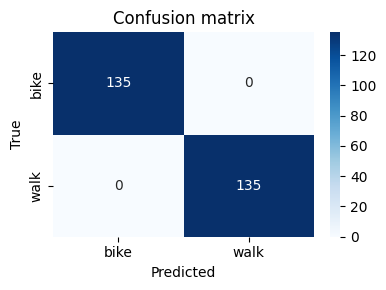

In [66]:
# 0. Imports ────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics  import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Config  ────────────────────────────────────────────────────────────────
TARGET_HZ    = 50         # common sample rate after resampling
WIN_SEC      = 5          # window length (seconds)
STRIDE_SEC   = 2          # window stride  (seconds)
WIN          = WIN_SEC   * TARGET_HZ
STRIDE       = STRIDE_SEC * TARGET_HZ

# 2. Make both sessions uniform (rename cols, resample, label) ──────────────
COMMON_COLS = [
    'Time (s)',
    'Accelerometer_df_X_m/s^2', 'Accelerometer_df_Y_m/s^2', 'Accelerometer_df_Z_m/s^2',
    'Linear Accelerometer_df_X_m/s^2', 'Linear Accelerometer_df_Y_m/s^2', 'Linear Accelerometer_df_Z_m/s^2',
    'Gyroscope_df_X_rad/s', 'Gyroscope_df_Y_rad/s', 'Gyroscope_df_Z_rad/s',
    'Barometer_df_X_hPa',
    'Location_df_Velocity_m/s',
    'turning_rate_deg/s',
    'activity'   # we’ll add this in a sec
]

# def prep_session(df, label, session_id):
#     df = df.copy()
#     df['activity']   = label
#     df['session_id'] = session_id          # handy later if you add more sessions
#     df = df[COMMON_COLS[:-1] + ['activity','session_id']]   # ensure col order
#     # ─ resample ─
#     df = df.set_index('Time (s)')
#     df = df.resample(f'{1000//TARGET_HZ}L').mean().interpolate()
#     df = df.reset_index()
#     return df

def prep_session(df, label, session_id):
    df = df.copy()

    # 1️⃣ turn "seconds-since-start" into a TimedeltaIndex
    # df['rel_time'] = pd.to_timedelta(df['Time (s)'] - df['Time (s immobilized)'].iloc[0], unit='s')
    df['rel_time'] = pd.to_timedelta(df['Time (s)'], unit='s') # Use 'Time (s)' instead


    df = df.set_index('rel_time')

    # Exclude non-numeric columns before resampling
    numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
    df_numeric = df[numeric_cols]

    # 2️⃣ NOW resample works
    ms_per_sample = int(1000 / TARGET_HZ)          # e.g. 20 ms for 50 Hz
    df_resampled = df_numeric.resample(f'{ms_per_sample}ms').mean()

    # Replace infinite values with NaN and interpolate
    df_resampled = df_resampled.replace([np.inf, -np.inf], np.nan).interpolate()


    # restore a simple row index (optional)
    df_resampled = df_resampled.reset_index(drop=True)

    # Add back activity and session_id columns
    df_resampled['activity'] = label
    df_resampled['session_id'] = session_id

    # keep only the columns you want, in order
    df_resampled = df_resampled[COMMON_COLS[:-1] + ['activity', 'session_id']]
    return df_resampled


walk   = prep_session(walking_df,  'walk',  0)
bike   = prep_session(biking_df,  'bike',  1)

full   = pd.concat([walk, bike], ignore_index=True)

# 3. Sliding-window feature extraction  ─────────────────────────────────────
def extract_features(chunk):
    f = []

    # --- raw accelerometer stats (X,Y,Z) -----------------------------------
    for axis in "XYZ":
        col = f'Accelerometer_df_{axis}_m/s^2'
        v   = chunk[col].values
        f += [v.mean(), v.std(), v.min(), v.max()]

    # --- magnitude of acceleration ----------------------------------------
    vmag = np.linalg.norm(chunk[
        [f'Accelerometer_df_{a}_m/s^2' for a in "XYZ"]].values, axis=1)
    f += [vmag.mean(), vmag.std()]

    # --- gyroscope ---------------------------------------------------------
    for axis in "XYZ":
        col = f'Gyroscope_df_{axis}_rad/s'
        v   = chunk[col].values
        f += [v.mean(), v.std()]

    # --- barometer ---------------------------------------------------------
    b = chunk['Barometer_df_X_hPa'].values
    f += [b.mean(), b.std(), b[-1] - b[0]]     # last-first drift

    # --- gps speed ---------------------------------------------------------
    s = chunk['Location_df_Velocity_m/s'].values
    f += [s.mean(), s.std(), np.percentile(s, 90), s.max()]

    # --- turning rate ------------------------------------------------------
    t = chunk['turning_rate_deg/s'].values
    f += [t.mean(), t.std()]

    return f

X_rows, y_rows = [], []

for session in [walk, bike]:
    data  = session.reset_index(drop=True)
    label = data['activity'].iloc[0]       # same label for the whole DF
    for start in range(0, len(data) - WIN, STRIDE):
        window = data.iloc[start : start + WIN]
        X_rows.append(extract_features(window))
        y_rows.append(label)

X = np.vstack(X_rows)      # shape → (n_windows, n_features)
y = np.array(y_rows)

print("Feature table:", X.shape)

# 4. Train/test split (time-ordered, no shuffle) ────────────────────────────
idx_walk = np.where(y == 'walk')[0]
idx_bike = np.where(y == 'bike')[0]

def chrono_split(indices, train_ratio=0.7):
    cut = int(len(indices) * train_ratio)
    return indices[:cut], indices[cut:]

tr_w, te_w = chrono_split(idx_walk)
tr_b, te_b = chrono_split(idx_bike)

train_idx  = np.concatenate([tr_w, tr_b])
test_idx   = np.concatenate([te_w, te_b])

X_train, y_train = X[train_idx], y[train_idx]
X_test,  y_test  = X[test_idx],  y[test_idx]

# 5. Random-Forest fit & evaluation ────────────────────────────────────────
rf = RandomForestClassifier(
        n_estimators=400,
        min_samples_leaf=2,
        n_jobs=-1,
        class_weight='balanced'
)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

print("\n--- classification report ---")
print(classification_report(y_test, y_pred))

# 6. Confusion matrix eye-candy ────────────────────────────────────────────
plt.figure(figsize=(4,3))
sns.heatmap(confusion_matrix(y_test, y_pred),
            annot=True, fmt='d', cmap='Blues',
            xticklabels=rf.classes_, yticklabels=rf.classes_)
plt.title("Confusion matrix")
plt.ylabel("True"); plt.xlabel("Predicted")
plt.tight_layout(); plt.show()

In [67]:
import numpy as np
from sklearn.metrics import f1_score # Import f1_score

# Get the feature names based on the extract_features function
feature_names = [
    f'Accelerometer_df_{axis}_m/s^2_mean' for axis in "XYZ"
] + [
    f'Accelerometer_df_{axis}_m/s^2_std' for axis in "XYZ"
] + [
    f'Accelerometer_df_{axis}_m/s^2_min' for axis in "XYZ"
] + [
    f'Accelerometer_df_{axis}_m/s^2_max' for axis in "XYZ"
] + [
    'Accelerometer_magnitude_mean', 'Accelerometer_magnitude_std'
] + [
    f'Gyroscope_df_{axis}_rad/s_mean' for axis in "XYZ"
] + [
    f'Gyroscope_df_{axis}_rad/s_std' for axis in "XYZ"
] + [
    'Barometer_df_X_hPa_mean', 'Barometer_df_X_hPa_std', 'Barometer_df_X_hPa_drift'
] + [
    'Location_df_Velocity_m/s_mean', 'Location_df_Velocity_m/s_std', 'Location_df_Velocity_m/s_90th_percentile', 'Location_df_Velocity_m/s_max'
] + [
    'turning_rate_deg/s_mean', 'turning_rate_deg/s_std'
]


# 1.  Which features did the forest actually use?
pd.Series(rf.feature_importances_, index=feature_names).sort_values(ascending=False).head(10)

# 2.  Does any one feature alone predict perfectly?
# Need to create a DataFrame from X with feature names to access columns by name
X_df = pd.DataFrame(X, columns=feature_names)

for col in X_df.columns:
    if len(np.unique(X_df[col])) < 5:       # suspiciously few unique values
        print(col, np.unique(X_df[col]))
        # Map 'walk' to 0 and 'bike' to 1 for comparison
        y_test_numeric = np.array([0 if label == 'walk' else 1 for label in y_test])
        print("Single-feature accuracy:",
              (X_df[col][test_idx] == y_test_numeric).mean())


# 3.  What if we drop session_id & activity and retrain?
# X already doesn't contain 'session_id' or 'activity' since they were excluded from feature extraction
rf2 = RandomForestClassifier(n_estimators=400).fit(X[train_idx], y_train)
print("New test F1:", f1_score(y_test, rf2.predict(X[test_idx]), average='macro'))

New test F1: 1.0


In [68]:
#f permuted labels still yield F1 ≈ 1 → definite leakage • If F1 ≈ 0.5 → the leak is gone; the original 100 % was genuine (speed-only).

import random, copy
y_shuffled = copy.deepcopy(y_train)
random.shuffle(list(y_shuffled))

rf_perm = RandomForestClassifier(n_estimators=400).fit(X_train, y_shuffled)
print("F1 after label permutation:",
      classification_report(y_test,
                            rf_perm.predict(X_test),
                            zero_division=0))


F1 after label permutation:               precision    recall  f1-score   support

        bike       1.00      1.00      1.00       135
        walk       1.00      1.00      1.00       135

    accuracy                           1.00       270
   macro avg       1.00      1.00      1.00       270
weighted avg       1.00      1.00      1.00       270



#6. DeepLearning Approach - LSTM

In [69]:
full_old = copy.deepcopy(full)

In [70]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming 'full' DataFrame is already created and contains 'Time (s)' and 'activity' columns
# and other sensor data columns.
# Ensure 'full' is sorted by 'Time (s)'
full = full.sort_values('Time (s)').reset_index(drop=True)

# Drop columns that are not suitable for direct LSTM input or are redundant
# Keep only the raw sensor data and the activity label
lstm_df = full[[
    'Time (s)',
    'Accelerometer_df_X_m/s^2', 'Accelerometer_df_Y_m/s^2', 'Accelerometer_df_Z_m/s^2',
    'Linear Accelerometer_df_X_m/s^2', 'Linear Accelerometer_df_Y_m/s^2', 'Linear Accelerometer_df_Z_m/s^2',
    'Gyroscope_df_X_rad/s', 'Gyroscope_df_Y_rad/s', 'Gyroscope_df_Z_rad/s',
    'Barometer_df_X_hPa',
    'Location_df_Velocity_m/s',
    'turning_rate_deg/s',
    'activity'
]].copy()

# Handle remaining missing values after interpolation - fill with 0 or a more sophisticated method
lstm_df.fillna(0, inplace=True) # Filling NaNs with 0 for simplicity, consider other strategies

# Normalize numerical features
# Exclude 'Time (s)' and 'activity' from scaling
feature_cols = [col for col in lstm_df.columns if col not in ['Time (s)', 'activity']]
scaler = StandardScaler()
lstm_df[feature_cols] = scaler.fit_transform(lstm_df[feature_cols])

# Convert activity labels to numerical format
activity_mapping = {'walk': 0, 'bike': 1}
lstm_df['activity'] = lstm_df['activity'].map(activity_mapping)

# Define sequence parameters
SEQUENCE_LENGTH = 50 # Number of time steps in each sequence
STEP_DISTANCE = 25   # How far to step for the next sequence (overlap)

# Create sequences
sequences = []
labels = []

# Iterate through the dataframe to create sequences
# Ensure we have enough data points for a full sequence
for i in range(0, len(lstm_df) - SEQUENCE_LENGTH, STEP_DISTANCE):
    seq = lstm_df.iloc[i : i + SEQUENCE_LENGTH][feature_cols].values
    # Assign the label based on the activity at the end of the sequence
    label = lstm_df['activity'].iloc[i + SEQUENCE_LENGTH - 1]
    sequences.append(seq)
    labels.append(label)

X_lstm = np.array(sequences)
y_lstm = np.array(labels)

# Convert labels to categorical (one-hot encoding)
y_lstm_categorical = to_categorical(y_lstm, num_classes=len(activity_mapping))

print("Shape of X_lstm:", X_lstm.shape)
print("Shape of y_lstm_categorical:", y_lstm_categorical.shape)

Shape of X_lstm: (3601, 50, 12)
Shape of y_lstm_categorical: (3601, 2)


In [71]:
# Split data while maintaining temporal order
# Use a fixed split point based on the total number of sequences
train_ratio = 0.7
split_index = int(len(X_lstm) * train_ratio)

X_train_lstm, X_test_lstm = X_lstm[:split_index], X_lstm[split_index:]
y_train_lstm, y_test_lstm = y_lstm_categorical[:split_index], y_lstm_categorical[split_index:]
y_test_lstm_non_categorical = y_lstm[split_index:] # Keep non-categorical for classification report

print("Shape of X_train_lstm:", X_train_lstm.shape)
print("Shape of X_test_lstm:", X_test_lstm.shape)
print("Shape of y_train_lstm:", y_train_lstm.shape)
print("Shape of y_test_lstm:", y_test_lstm.shape)

Shape of X_train_lstm: (2520, 50, 12)
Shape of X_test_lstm: (1081, 50, 12)
Shape of y_train_lstm: (2520, 2)
Shape of y_test_lstm: (1081, 2)


In [72]:
# Build the LSTM model
model = Sequential()
model.add(LSTM(units=64, return_sequences=True, input_shape=(SEQUENCE_LENGTH, len(feature_cols))))
model.add(Dropout(0.2))
model.add(LSTM(units=64))
model.add(Dropout(0.2))
model.add(Dense(units=len(activity_mapping), activation='softmax')) # Output layer for classification

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50, 64)         │        19,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 50, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,866 (206.51 KB)

 Trainable params: 52,866 (206.51 KB)

 Non-trainable params: 0 (0.00 B)

In [73]:
# Train the LSTM model
history = model.fit(X_train_lstm, y_train_lstm, epochs=10, batch_size=32, validation_split=0.2)

Epoch 1/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 12s 73ms/step - accuracy: 0.5033 - loss: 0.6992 - val_accuracy: 0.5635 - val_loss: 0.6839
Epoch 2/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step - accuracy: 0.6261 - loss: 0.6711 - val_accuracy: 0.9762 - val_loss: 0.4588
Epoch 3/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 56ms/step - accuracy: 0.9791 - loss: 0.1818 - val_accuracy: 1.0000 - val_loss: 7.5501e-04
Epoch 4/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 52ms/step - accuracy: 1.0000 - loss: 9.7908e-04 - val_accuracy: 1.0000 - val_loss: 5.1666e-04
Epoch 5/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 68ms/step - accuracy: 1.0000 - loss: 6.8661e-04 - val_accuracy: 1.0000 - val_loss: 3.8969e-04
Epoch 6/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 54ms/step - accuracy: 1.0000 - loss: 5.5678e-04 - val_accuracy: 1.0000 - val_loss: 3.0753e-04
Epoch 7/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 60ms/step - accuracy: 1.0000 - loss: 4.3473e-04 - val_accuracy: 1.0000 - val_loss: 2.4973e-04
Epoch 8/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 80ms/step - accuracy: 1.0000 - lo

Test Loss: 0.0001
Test Accuracy: 1.0000
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step

--- Classification Report ---
              precision    recall  f1-score   support

        bike       1.00      1.00      1.00       540
        walk       1.00      1.00      1.00       541

    accuracy                           1.00      1081
   macro avg       1.00      1.00      1.00      1081
weighted avg       1.00      1.00      1.00      1081



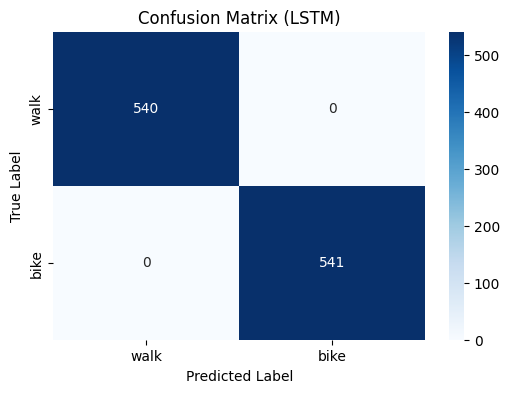

In [74]:
# Evaluate the LSTM model
loss, accuracy = model.evaluate(X_test_lstm, y_test_lstm, verbose=0)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

# Make predictions
y_pred_lstm = model.predict(X_test_lstm)
y_pred_lstm_classes = np.argmax(y_pred_lstm, axis=1)

# Generate classification report
# Map numerical predictions back to original labels for the report
reverse_activity_mapping = {v: k for k, v in activity_mapping.items()}
y_test_lstm_labels = [reverse_activity_mapping[i] for i in y_test_lstm_non_categorical]
y_pred_lstm_labels = [reverse_activity_mapping[i] for i in y_pred_lstm_classes]

print("\n--- Classification Report ---")
print(classification_report(y_test_lstm_labels, y_pred_lstm_labels))

# Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test_lstm_labels, y_pred_lstm_labels),
            annot=True, fmt='d', cmap='Blues',
            xticklabels=activity_mapping.keys(), yticklabels=activity_mapping.keys())
plt.title("Confusion Matrix (LSTM)")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.show()